![](https://raw.githubusercontent.com/Qinbf/tf-model-zoo/master/README_IMG/01.jpg)
AI MOOC： **www.ai-xlab.com**  
如果你也是AI爱好者，可以添加我的微信一起交流：**sdxxqbf**

In [1]:
import numpy as np
from numpy import genfromtxt
import matplotlib.pyplot as plt  
from mpl_toolkits.mplot3d import Axes3D  

In [3]:
# 读入数据 
data = genfromtxt(r"Delivery.csv",delimiter=',')
print(data)
print(data.shape)

[[100.    4.    9.3]
 [ 50.    3.    4.8]
 [100.    4.    8.9]
 [100.    2.    6.5]
 [ 50.    2.    4.2]
 [ 80.    2.    6.2]
 [ 75.    3.    7.4]
 [ 65.    4.    6. ]
 [ 90.    3.    7.6]
 [ 90.    2.    6.1]]
(10, 3)


In [ ]:
# 切分数据
x_data = data[:,:-1] 
y_data = data[:,-1]
y_data_T = y_data.reshape(-1,1) 
#In this method, -1 tells NumPy to automatically calculate the size of dimension, 1 explicitly sets the number of columns to one.
print(x_data)
print(y_data)
print(y_data_T)
print(type(x_data))
print(type(y_data))
print(type(y_data_T))


[[100.   4.]
 [ 50.   3.]
 [100.   4.]
 [100.   2.]
 [ 50.   2.]
 [ 80.   2.]
 [ 75.   3.]
 [ 65.   4.]
 [ 90.   3.]
 [ 90.   2.]]
[9.3 4.8 8.9 6.5 4.2 6.2 7.4 6.  7.6 6.1]
[[9.3]
 [4.8]
 [8.9]
 [6.5]
 [4.2]
 [6.2]
 [7.4]
 [6. ]
 [7.6]
 [6.1]]
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [12]:
# 学习率learning rate
lr = 0.0001
# 参数
theta0 = 0
theta1 = 0
theta2 = 0
# 最大迭代次数
epochs = 1000

# 最小二乘法
def compute_error(theta0, theta1, theta2, x_data, y_data):
    totalError = 0
    for i in range(0, len(x_data)):
        totalError += (y_data[i] - (theta1 * x_data[i,0] + theta2*x_data[i,1] + theta0)) ** 2
    return totalError / float(len(x_data))

def gradient_descent_runner(x_data, y_data, theta0, theta1, theta2, lr, epochs):
    # 计算总数据量
    m = float(len(x_data))
    # 循环epochs次
    for i in range(epochs):
        theta0_grad = 0
        theta1_grad = 0
        theta2_grad = 0
        # 计算梯度的总和再求平均
        for j in range(0, len(x_data)):
            theta0_grad += (1/m) * ((theta1 * x_data[j,0] + theta2*x_data[j,1] + theta0) - y_data[j])
            theta1_grad += (1/m) * x_data[j,0] * ((theta1 * x_data[j,0] + theta2*x_data[j,1] + theta0) - y_data[j])
            theta2_grad += (1/m) * x_data[j,1] * ((theta1 * x_data[j,0] + theta2*x_data[j,1] + theta0) - y_data[j])
        # 更新b和k
        theta0 = theta0 - (lr*theta0_grad)
        theta1 = theta1 - (lr*theta1_grad)
        theta2 = theta2 - (lr*theta2_grad)
    return theta0, theta1, theta2

In [13]:
print("Starting theta0 = {0}, theta1 = {1}, theta2 = {2}, error = {3}".
      format(theta0, theta1, theta2, compute_error(theta0, theta1, theta2, x_data, y_data)))
print("Running...")
theta0, theta1, theta2 = gradient_descent_runner(x_data, y_data, theta0, theta1, theta2, lr, epochs)
print("After {0} iterations theta0 = {1}, theta1 = {2}, theta2 = {3}, error = {4}".
      format(epochs, theta0, theta1, theta2, compute_error(theta0, theta1, theta2, x_data, y_data)))

Starting theta0 = 0, theta1 = 0, theta2 = 0, error = 47.279999999999994
Running...
After 1000 iterations theta0 = 0.006971416196678632, theta1 = 0.08021042690771771, theta2 = 0.07611036240566814, error = 0.7731271432218118


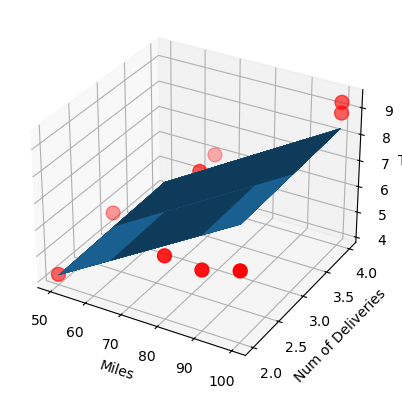

In [18]:
ax = plt.figure().add_subplot(111, projection = '3d') # <<<<==================== 3D图的关键代码
ax.scatter(x_data[:,0], x_data[:,1], y_data, c = 'r', marker = 'o', s = 100) #点为红色三角形  
x0 = x_data[:,0]
x1 = x_data[:,1]

# 生成网格矩阵
x0, x1 = np.meshgrid(x0, x1)
z = theta0 + x0*theta1 + x1*theta2

# 画3D图
ax.plot_surface(x0, x1, z)

#设置坐标轴  
ax.set_xlabel('Miles')  
ax.set_ylabel('Num of Deliveries')  
ax.set_zlabel('Time')  
  
#显示图像  
plt.show()  